In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Helper function to display results side-by-side
def show_images(titles, images, cmap=None):
    plt.figure(figsize=(15, 5))
    for i in range(len(images)):
        plt.subplot(1, len(images), i + 1)
        curr_cmap = cmap if len(images[i].shape) == 2 else None
        plt.imshow(images[i], cmap=curr_cmap)
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

Successfully loaded pair:
 FPWW0220011_RGB1_20180316_100219_6.png
 FPWW0220011_RGB1_20180316_100219_6_mask.png


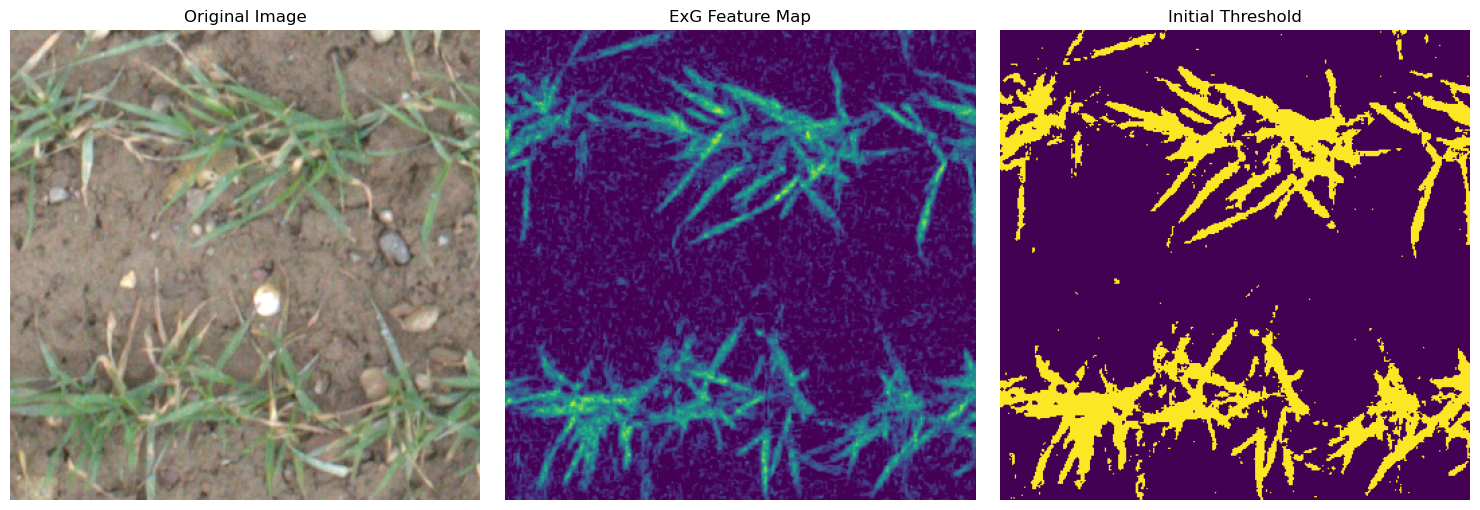

In [2]:
train_dir = Path(r'EWS-Dataset/train') 
image_files = [f for f in train_dir.glob('*.png') if '_mask' not in f.name]

if not image_files:
    print(f"No images found. Check your path: {train_dir}")
else:
    # Process the first image for testing the pipeline
    img_path = image_files[0]
    mask_path = img_path.parent / f"{img_path.stem}_mask.png"

    # Load the files
    img = cv2.imread(str(img_path))
    gt_mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    _, gt_mask_bin = cv2.threshold(gt_mask, 127, 255, cv2.THRESH_BINARY)

    if img is None or gt_mask is None:
        print(f"Error loading files.\n Image: {img_path}\n Mask: {mask_path}")
    else:
        print(f"Successfully loaded pair:\n {img_path.name}\n {mask_path.name}")
        
        # Convert for visualization
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Feature-based Pixel Classification: Excess Green (ExG)
        # As discussed in the lecture, we use color features to isolate the crop 
        b, g, r = cv2.split(img)
        exg = 2.0 * g.astype(np.float32) - r.astype(np.float32) - b.astype(np.float32)
        exg = np.clip(exg, 0, 255).astype(np.uint8)
        
        # Otsu's Thresholding to get an initial binary mask
        _, thresh = cv2.threshold(exg, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        show_images(['Original Image', 'ExG Feature Map', 'Initial Threshold'], 
                    [img_rgb, exg, thresh])

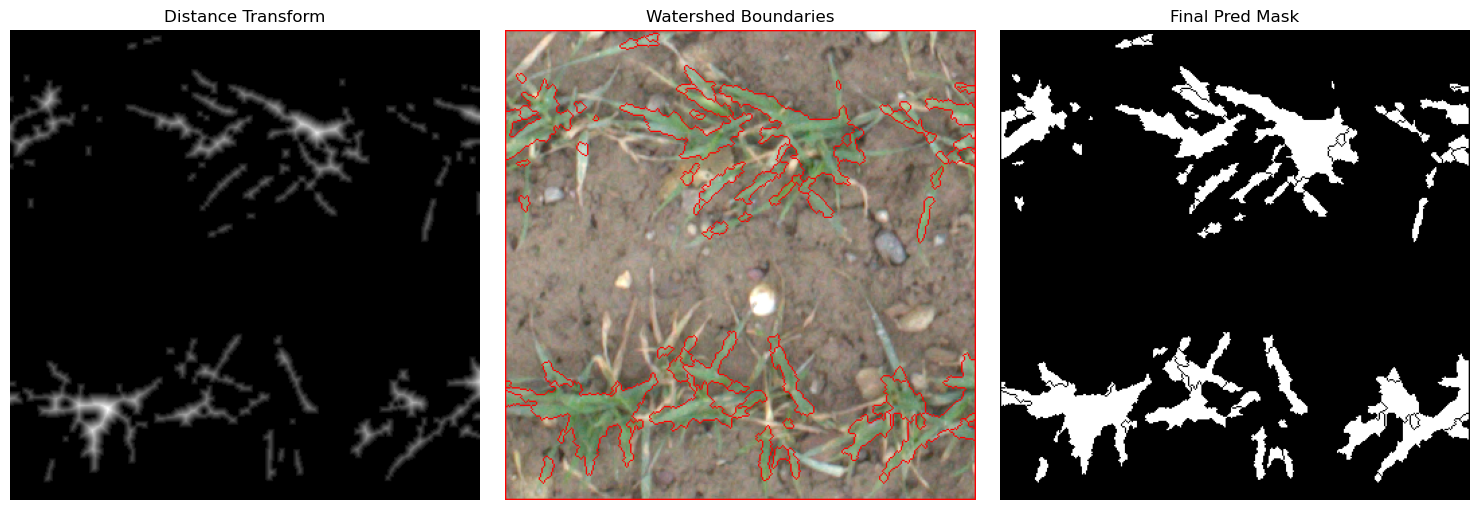

In [3]:
# Morphological Opening to remove small noise (small weeds/soil reflections)
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Find sure background area (dilate the object)
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Find sure foreground area using Distance Transform
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.2 * dist_transform.max(), 255, 0)

# Find unknown region (boundaries where leaves touch)
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

# Marker labelling
_, markers = cv2.connectedComponents(sure_fg)

# Add 1 to all labels so that sure background is 1 instead of 0
markers = markers + 1
# Mark the unknown region with 0
markers[unknown == 255] = 0

# Apply Watershed
markers = cv2.watershed(img, markers)

# Create a final binary segmentation mask from Watershed results
# Everything strictly greater than 1 is our segmented wheat crop
pred_mask = np.zeros_like(markers, dtype=np.uint8)
pred_mask[markers > 1] = 255

# Visualize the boundaries drawn by Watershed in red
img_result = img_rgb.copy()
img_result[markers == -1] = [255, 0, 0]

show_images(['Distance Transform', 'Watershed Boundaries', 'Final Pred Mask'], 
            [dist_transform, img_result, pred_mask], cmap='gray')

Verification Results:

Sensitivity (Recall): 0.0154
Precision:          0.0849
Jaccard Coef (IoU): 0.0132
Dice Coef (F1):     0.0260


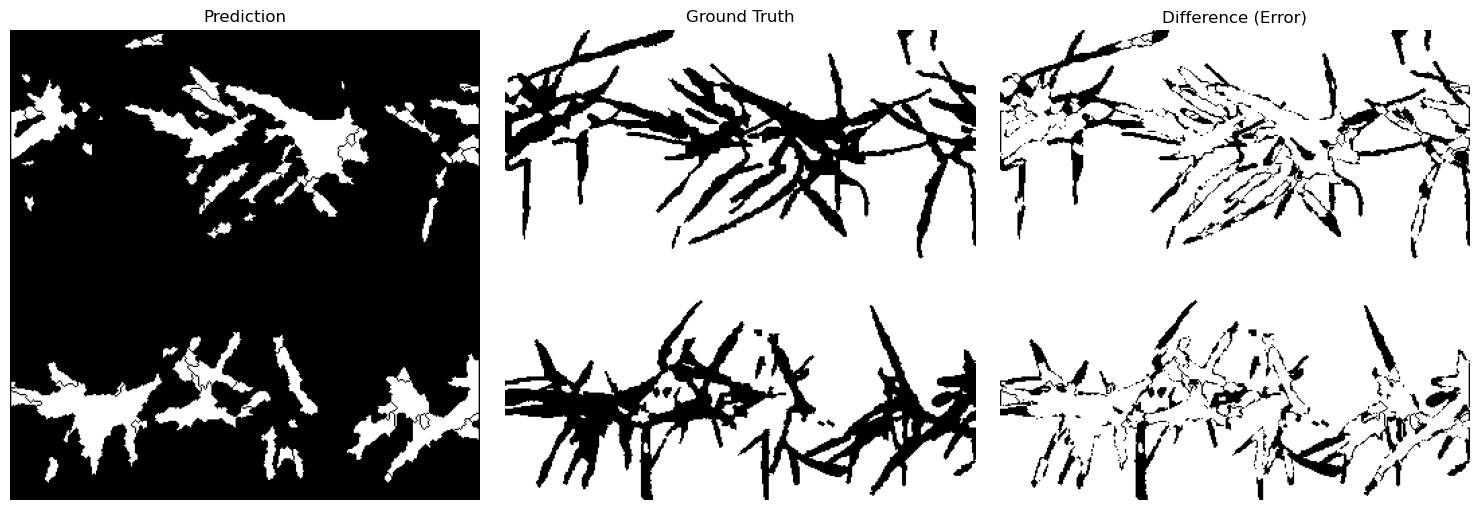

In [4]:
def calculate_metrics(pred, gt):
    # Ensure binary arrays (0 or 1)
    p = (pred > 127).astype(np.uint8)
    g = (gt > 127).astype(np.uint8)
    
    # Calculate intersection and union
    intersection = np.sum(p * g)
    union = np.sum(p) + np.sum(g) - intersection
    
    # True Positives, False Positives, False Negatives
    TP = intersection
    FP = np.sum(p) - TP
    FN = np.sum(g) - TP
    
    # Sensitivity / Recall (True Positive Rate)
    sensitivity = TP / (TP + FN + 1e-6)
    
    # Precision
    precision = TP / (TP + FP + 1e-6)
    
    # Jaccard Similarity Coefficient (IoU)
    iou = TP / (union + 1e-6)
    
    # Dice Similarity Coefficient (F1 Score)
    dice = (2 * TP) / (np.sum(p) + np.sum(g) + 1e-6)
    
    return sensitivity, precision, iou, dice

# Run verification
sens, prec, iou, dice = calculate_metrics(pred_mask, gt_mask_bin)

print("Verification Results:\n")
print(f"Sensitivity (Recall): {sens:.4f}")
print(f"Precision:          {prec:.4f}")
print(f"Jaccard Coef (IoU): {iou:.4f}")
print(f"Dice Coef (F1):     {dice:.4f}")

# Visual comparison
show_images(['Prediction', 'Ground Truth', 'Difference (Error)'], 
            [pred_mask, gt_mask_bin, cv2.absdiff(pred_mask, gt_mask_bin)], cmap='gray')

In [7]:
import pandas as pd 

# Define the subsets to process
subsets = ['train', 'validation', 'test'] 
dataset_root = Path(r'EWS-Dataset') 

all_results = {}

print("Starting full dataset evaluation")

for subset in subsets:
    subset_path = dataset_root / subset
    if not subset_path.exists():
        print(f"Skipping {subset}: Folder not found.")
        continue
        
    # Get only the images
    image_files = [f for f in subset_path.glob('*.png') if '_mask' not in f.name]
    
    # Store metrics for this subset
    subset_metrics = {'iou': [], 'dice': [], 'precision': [], 'recall': []}
    
    print(f"Processing {len(image_files)} images in '{subset}'")
    
    for img_path in image_files:
        # Construct mask path
        mask_path = img_path.parent / f"{img_path.stem}_mask.png"
        
        # Load pair
        img = cv2.imread(str(img_path))
        gt_mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        
        if img is None or gt_mask is None:
            continue
            
        # Feature Extraction 
        b, g, r = cv2.split(img)
        exg = 2.0 * g.astype(np.float32) - r.astype(np.float32) - b.astype(np.float32)
        exg = np.clip(exg, 0, 255).astype(np.uint8)
        _, thresh = cv2.threshold(exg, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        # Watershed Segmentation 
        kernel = np.ones((3,3), np.uint8)
        opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
        dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
        _, sure_fg = cv2.threshold(dist_transform, 0.2 * dist_transform.max(), 255, 0)
        
        # Markers and Watershed
        _, markers = cv2.connectedComponents(np.uint8(sure_fg))
        markers = markers + 1
        unknown = cv2.subtract(cv2.dilate(opening, kernel, iterations=3), np.uint8(sure_fg))
        markers[unknown == 255] = 0
        markers = cv2.watershed(img, markers)
        
        # Final Prediction Mask
        pred_mask = np.zeros_like(markers, dtype=np.uint8)
        pred_mask[markers > 1] = 255
        
        # Evaluation Metrics
        # Using the calculate_metrics function from the previous cell
        sens, prec, iou, dice = calculate_metrics(pred_mask, gt_mask)
        
        subset_metrics['iou'].append(iou)
        subset_metrics['dice'].append(dice)
        subset_metrics['precision'].append(prec)
        subset_metrics['recall'].append(sens)
        
    # Calculate means for the subset
    all_results[subset] = {k: np.mean(v) for k, v in subset_metrics.items()}

# Display Final Summary
print("FINAL EVALUATION SUMMARY")
for subset, scores in all_results.items():
    print(f"\nSubset: {subset.upper()}")
    print(f" - Mean Jaccard (IoU): {scores['iou']:.4f}")
    print(f" - Mean F1 Score:      {scores['dice']:.4f}")
    print(f" - Mean Precision:     {scores['precision']:.4f}")
    print(f" - Mean Recall:        {scores['recall']:.4f}")

Starting full dataset evaluation
Processing 142 images in 'train'
Processing 24 images in 'validation'
Processing 24 images in 'test'
FINAL EVALUATION SUMMARY

Subset: TRAIN
 - Mean Jaccard (IoU): 0.0152
 - Mean F1 Score:      0.0296
 - Mean Precision:     0.1566
 - Mean Recall:        0.0213

Subset: VALIDATION
 - Mean Jaccard (IoU): 0.0123
 - Mean F1 Score:      0.0241
 - Mean Precision:     0.1199
 - Mean Recall:        0.0199

Subset: TEST
 - Mean Jaccard (IoU): 0.0144
 - Mean F1 Score:      0.0284
 - Mean Precision:     0.1506
 - Mean Recall:        0.0207
